In [1]:
%pip install pandas
%pip install yfinance
%pip install matplotlib
%pip install scipy
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 17.2 MB/s  0:00:00 eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]
Note: you may need to restart the kernel to use updated packages.


# Fama-French dataset

It's worth noting that 1.00 in this dataset means 1%, not 100%

[[1]](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) Dartmouth College, French, K.R (2025) *Current Research Returns* Available at: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html (Accessed: 17 December 2025)

In [1]:
from pandas import DataFrame, read_csv

path: str = "data/F-F_Research_Data_5_Factors_2x3_daily.csv"
fama_french: DataFrame = read_csv(path)

In [2]:
fama_french.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15690 entries, 19630701 to 20251031
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  15690 non-null  float64
 1   SMB     15690 non-null  float64
 2   HML     15690 non-null  float64
 3   RMW     15690 non-null  float64
 4   CMA     15690 non-null  float64
 5   RF      15690 non-null  float64
dtypes: float64(6)
memory usage: 858.0 KB


In [3]:
fama_french.index.dtype

dtype('int64')

In [4]:
fama_french.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
19630701,-0.67,0.00,-0.34,-0.01,0.16,0.01
19630702,0.79,-0.26,0.26,-0.07,-0.20,0.01
19630703,0.63,-0.17,-0.09,0.18,-0.34,0.01
19630705,0.40,0.08,-0.27,0.09,-0.34,0.01
19630708,-0.63,0.04,-0.18,-0.29,0.14,0.01


In [5]:
fama_french.isna().sum()

Mkt-RF    0
SMB       0
HML       0
RMW       0
CMA       0
RF        0
dtype: int64

In [6]:
from pandas import to_datetime
fama_french.index = to_datetime(fama_french.index, format = "%Y%m%d").strftime("%Y-%m-%d")
fama_french.index = fama_french.index.astype("datetime64[ns]")

In [7]:
fama_french.index.dtype

dtype('<M8[ns]')

<Axes: title={'center': 'Fama-French Cumulative'}, xlabel='Date', ylabel='%'>

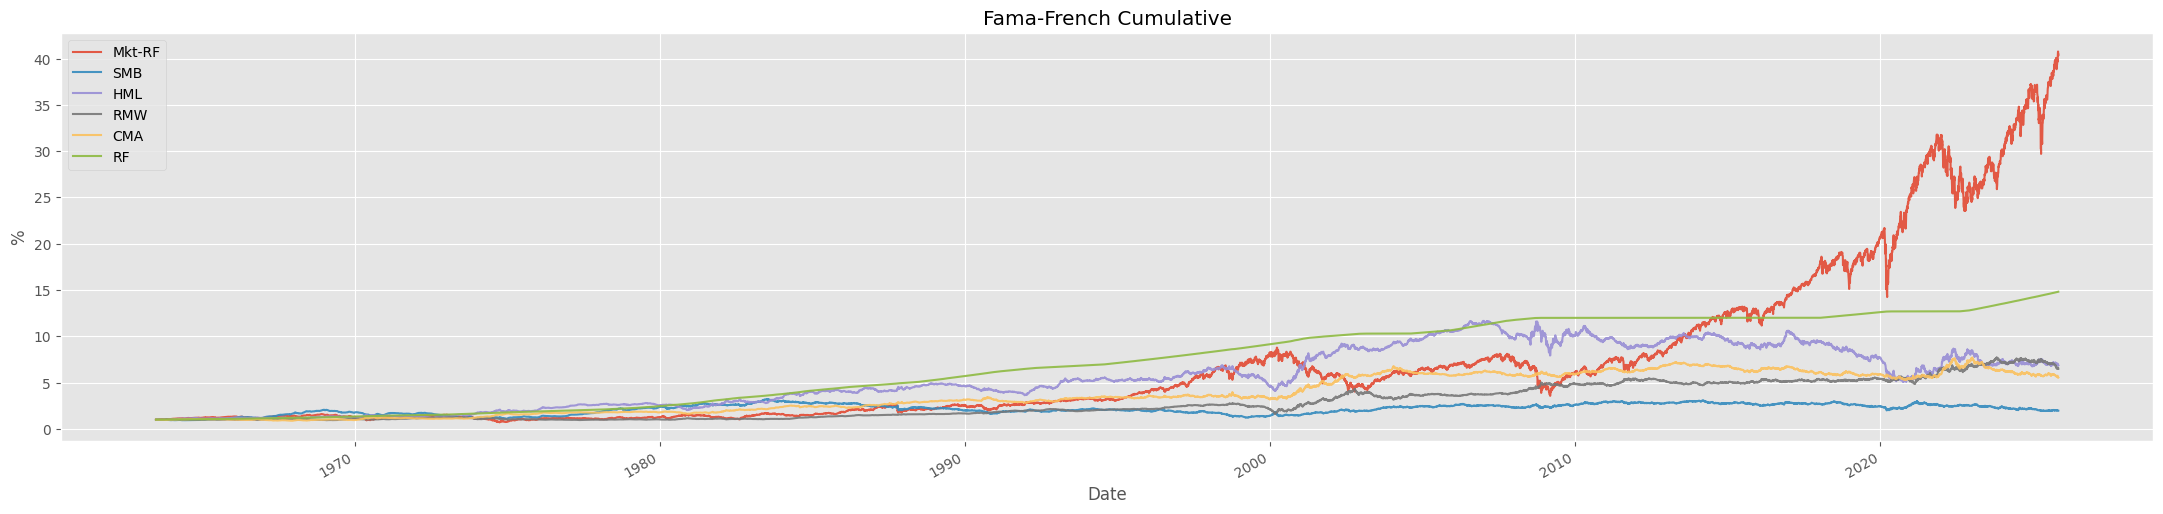

In [8]:
import matplotlib.pyplot as plt
from pandas import DataFrame

plt.style.use("ggplot")

fama_french_percentage: DataFrame = (1 + fama_french / 100) # converts ie. 1.00 = 1% -> 0.01 = 1%
fama_french_percentage_cumprod: DataFrame = fama_french_percentage.cumprod()
fama_french_percentage_cumprod.plot(grid = True, figsize = (27, 6), alpha = 0.9, title = "Fama-French Cumulative", xlabel = "Date", ylabel = "%")

# Ticker market dataset

Collection of some arbitrary markets that may be interesting to plot and train with; leaning towards Apple, AAPL, just because, but really valid ticker is possible

In [9]:
from yfinance import download
from pandas import DataFrame
market: dict = {
  "LLOY.L": "Lloyds Banking Group plc", 
  "HSBC": "HSBC Holdings plc",
  "AAPL": "Apple Inc",
  "NVDA": "NVIDIA Corporation",
  "TSCO.L": "Tesco PLC"
}
if (fetched_tickers := download(list(market.keys()), start = "2000-01-01", end = "2024-12-31")) is None: 
  raise ValueError("Error with the market ticker keys, check again against Yahoo Finance for the correct details") 

tickers: DataFrame = fetched_tickers

/tmp/ipykernel_8817/527689257.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  if (fetched_tickers := download(list(market.keys()), start = "2000-01-01", end = "2024-12-31")) is None:
[*********************100%***********************]  5 of 5 completed


In [10]:
tickers.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6450 entries, 2000-01-03 to 2024-12-30
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, AAPL)     6288 non-null   float64
 1   (Close, HSBC)     6288 non-null   float64
 2   (Close, LLOY.L)   6364 non-null   float64
 3   (Close, NVDA)     6288 non-null   float64
 4   (Close, TSCO.L)   6364 non-null   float64
 5   (High, AAPL)      6288 non-null   float64
 6   (High, HSBC)      6288 non-null   float64
 7   (High, LLOY.L)    6364 non-null   float64
 8   (High, NVDA)      6288 non-null   float64
 9   (High, TSCO.L)    6364 non-null   float64
 10  (Low, AAPL)       6288 non-null   float64
 11  (Low, HSBC)       6288 non-null   float64
 12  (Low, LLOY.L)     6364 non-null   float64
 13  (Low, NVDA)       6288 non-null   float64
 14  (Low, TSCO.L)     6364 non-null   float64
 15  (Open, AAPL)      6288 non-null   float64
 16  (Open, HSBC)      6288 n

In [11]:
tickers.index.dtype

dtype('<M8[ns]')

In [12]:
tickers.head()

Price          Close                                                   High  \
Ticker          AAPL       HSBC      LLOY.L      NVDA      TSCO.L      AAPL   
Date                                                                          
2000-01-03  0.839281  19.393660  497.945465  0.089415  236.190338  0.843498   
2000-01-04  0.768521  18.210487  466.763641  0.087028  228.034912  0.829440   
2000-01-05  0.779767  18.107616  466.120697  0.084163  231.798935  0.828971   
2000-01-06  0.712287  17.593191  450.690552  0.078671  231.798935  0.802260   
2000-01-07  0.746027  18.090469  434.938721  0.079985  228.662292  0.757274   

Price                                                    ...      Open  \
Ticker           HSBC      LLOY.L      NVDA      TSCO.L  ...      AAPL   
Date                                                     ...             
2000-01-03  19.616575  497.945465  0.090967  236.190338  ...  0.786328   
2000-01-04  18.656319  466.763641  0.088102  237.131283  ...  0.811633   
2000-01-05  18.193353  466.120697  0.085953  233.994635  ...  0.777893   
2000-01-06  17.661781  450.690552  0.084163  234.621934  ...  0.795700   
2000-01-07  18.090469  434.938721  0.080820  237.131273  ...  0.723534   

Price                                                         Volume  \
Ticker           HSBC      LLOY.L      NVDA      TSCO.L         AAPL   
Date                                                                   
2000-01-03  19.599428  497.945465  0.090251  236.190338  535796800.0   
2000-01-04  18.399108  466.763641  0.087863  237.131283  512377600.0   
2000-01-05  17.764669  466.120697  0.084521  220.820663  778321600.0   
2000-01-06  17.558896  450.690552  0.084163  231.798935  767972800.0   
2000-01-07  17.490312  434.938721  0.078313  234.621879  460734400.0   

Price                                                      
Ticker          HSBC      LLOY.L         NVDA      TSCO.L  
Date                                                       
2000-01-03   59500.0         0.0  300912000.0         0.0  
2000-01-04   84500.0  21285517.0  300480000.0  11214410.0  
2000-01-05  118200.0  26030803.0  188352000.0   9228302.0  
2000-01-06  105400.0  43870695.0  120480000.0  11398336.0  
2000-01-07  117700.0  38938371.0   71184000.0  13505834.0  

[5 rows x 25 columns]

In [13]:
tickers.isna().sum()

Price   Ticker
Close   AAPL      162
        HSBC      162
        LLOY.L     86
        NVDA      162
        TSCO.L     86
High    AAPL      162
        HSBC      162
        LLOY.L     86
        NVDA      162
        TSCO.L     86
Low     AAPL      162
        HSBC      162
        LLOY.L     86
        NVDA      162
        TSCO.L     86
Open    AAPL      162
        HSBC      162
        LLOY.L     86
        NVDA      162
        TSCO.L     86
Volume  AAPL      162
        HSBC      162
        LLOY.L     86
        NVDA      162
        TSCO.L     86
dtype: int64

In [14]:
import matplotlib.pyplot as plt
import matplotlib.axes as ax
#TODO- live hover it needed to make sure lines more visable

plt.style.use("ggplot")

def plot_ticker(ticker: str):
  """ General plot for ticker information
  """
  figure, axes = plt.subplots(1, 1)
  figure.set_figwidth(27)
  figure.set_figheight(6)
  figure.suptitle(ticker)

  axes.plot(tickers["Open"][ticker], alpha = 0.2, color = "yellow")
  axes.plot(tickers["Close"][ticker], color = "purple")
  axes.plot(tickers["High"][ticker], alpha = 0.5, color = "green")
  axes.plot(tickers["Low"][ticker], alpha = 0.5, color = "red")
  axes.set_ylabel("$")
  axes.set_xlabel("Date")
  axes_ext: ax.Axes = axes.twinx()

  axes_ext.bar(tickers.index, tickers["Volume"][ticker], color = "grey", alpha = 0.5)
  axes_ext.set_ylabel("Volumes")
  axes_ext.set_xlabel("Date")

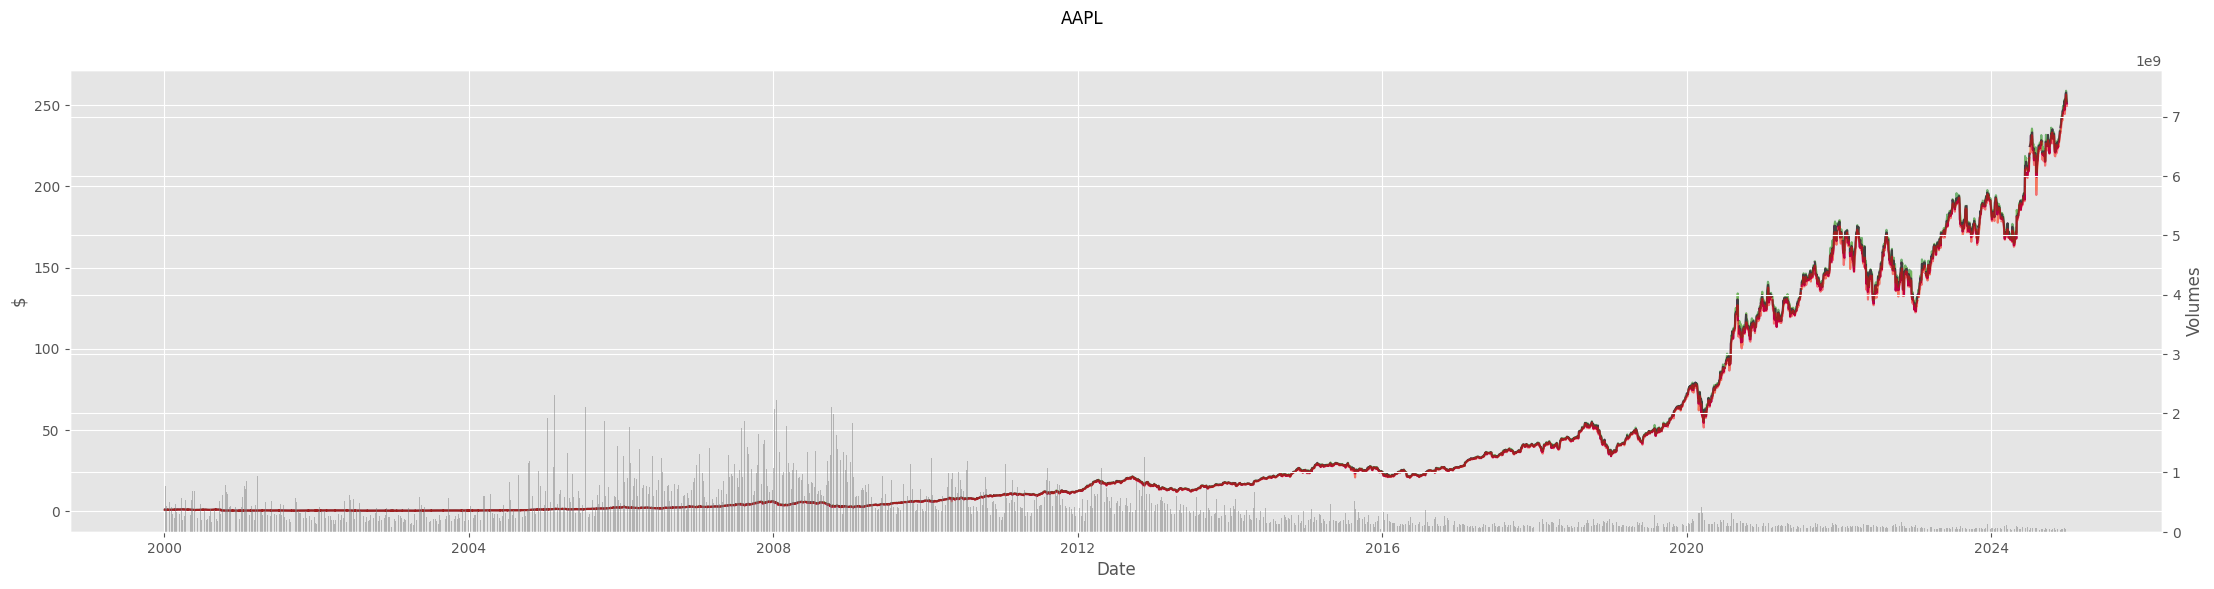

In [15]:
plot_ticker("AAPL")

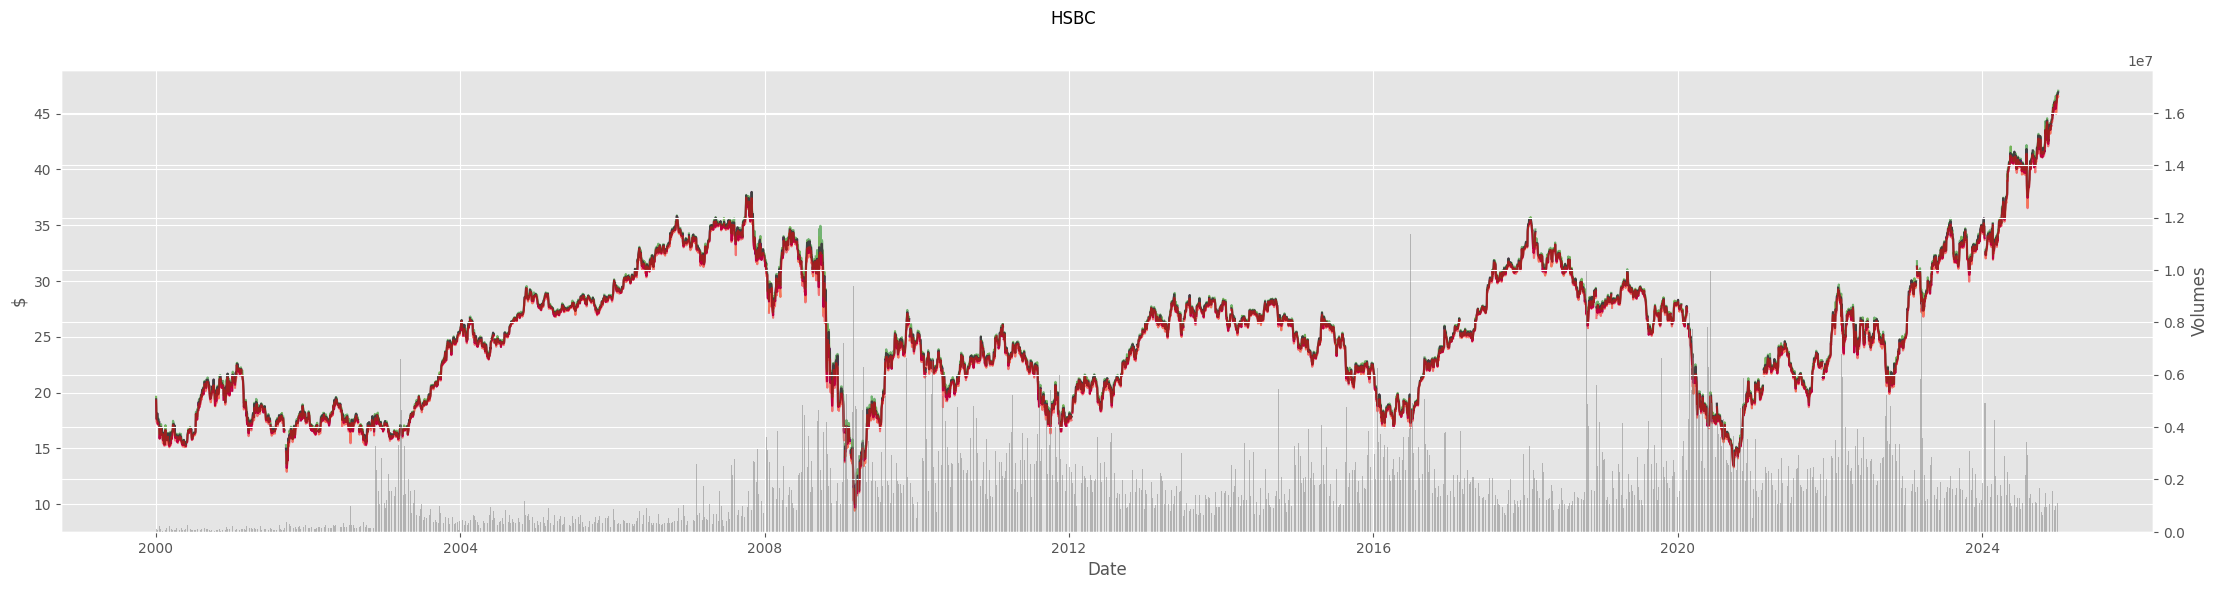

In [16]:
plot_ticker("HSBC")

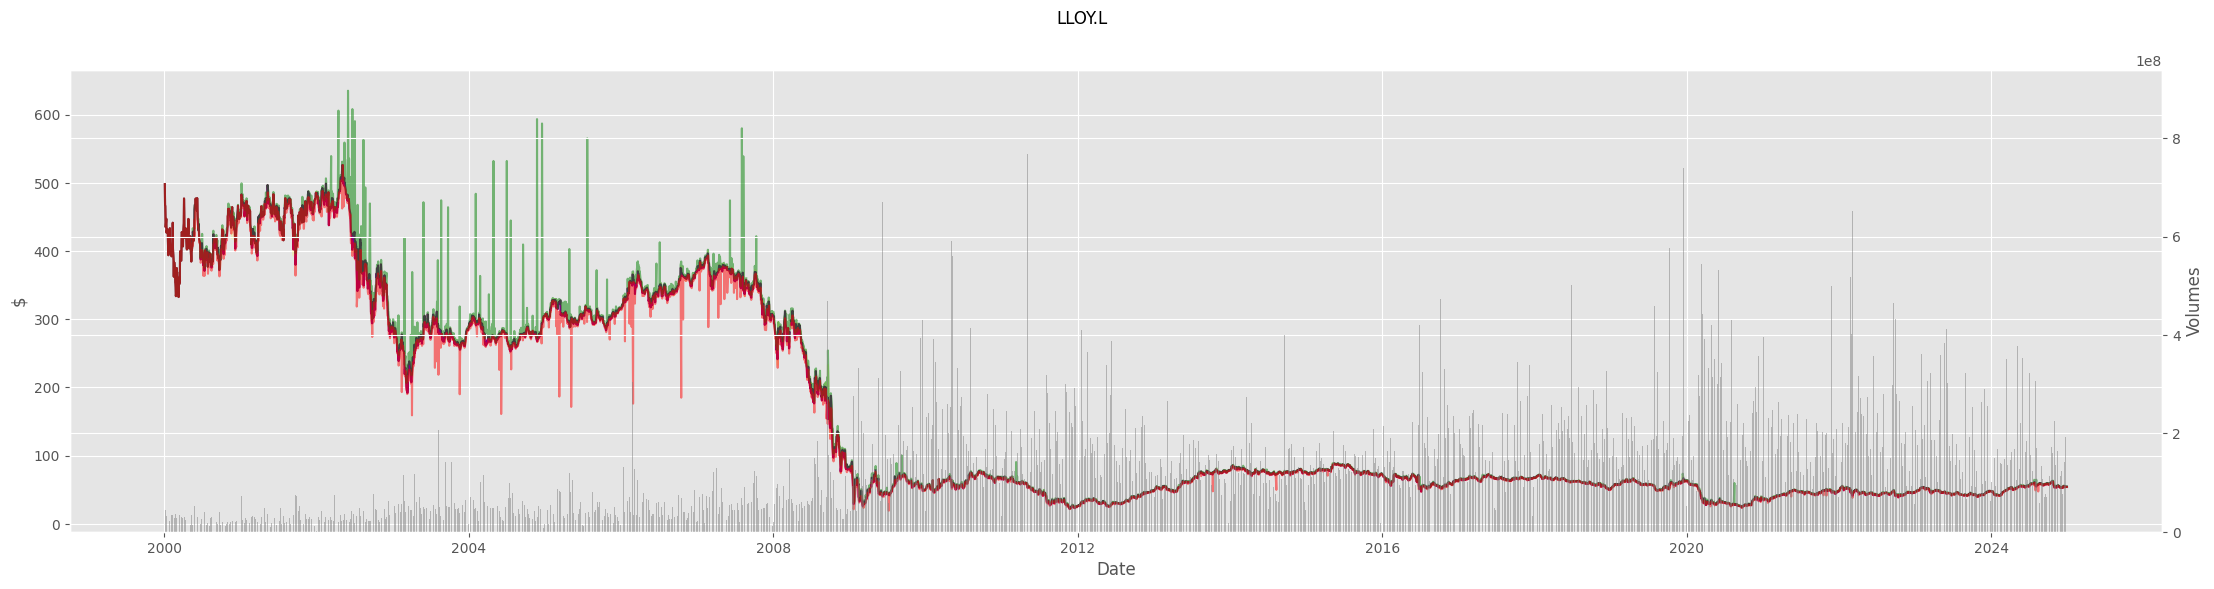

In [17]:
plot_ticker("LLOY.L")

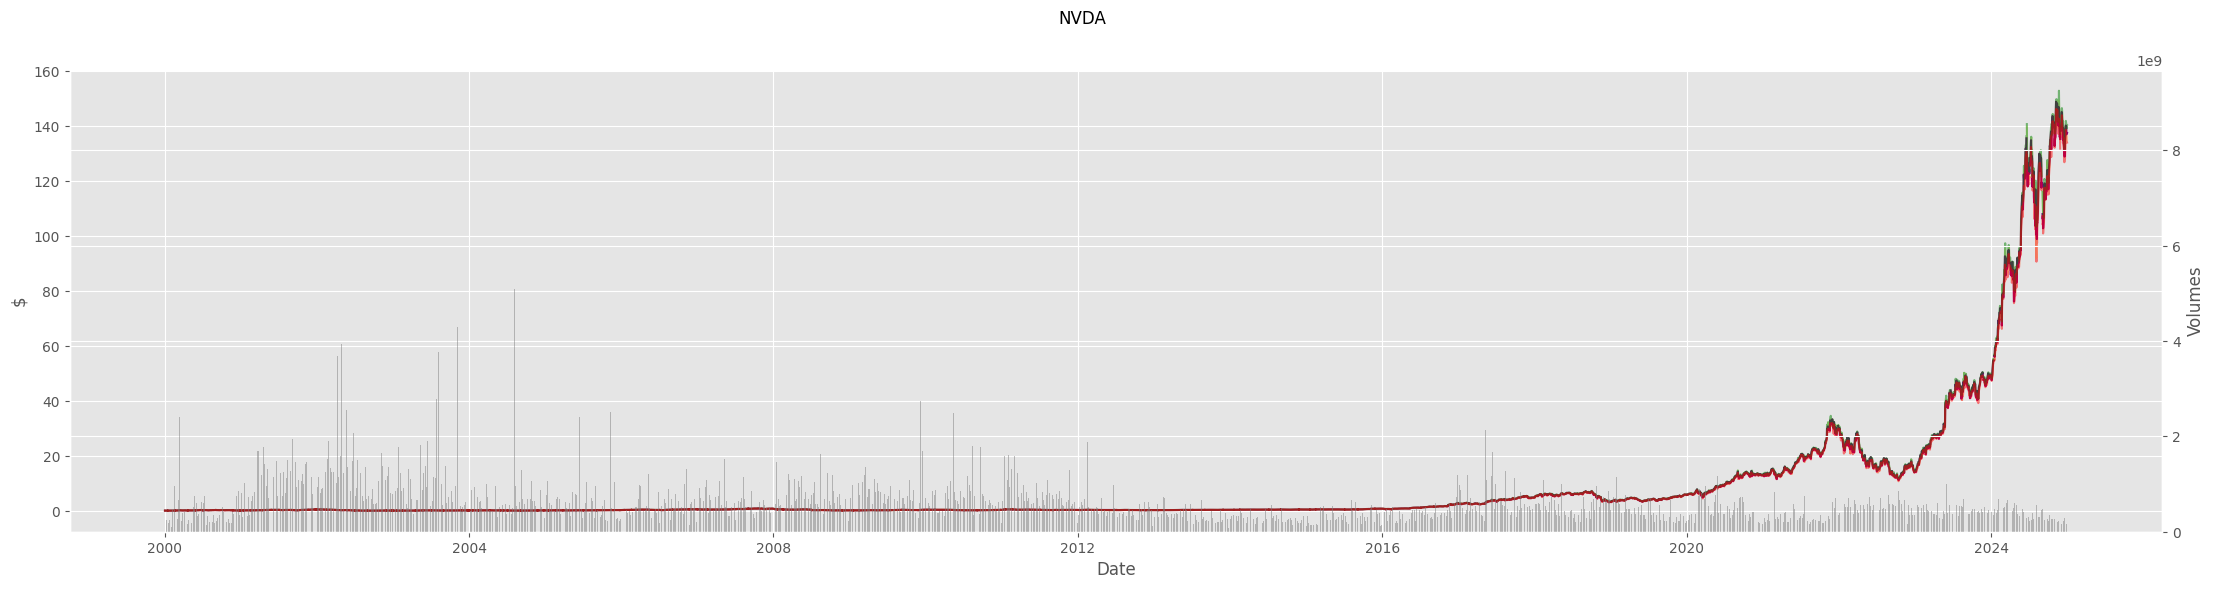

In [18]:
plot_ticker("NVDA")

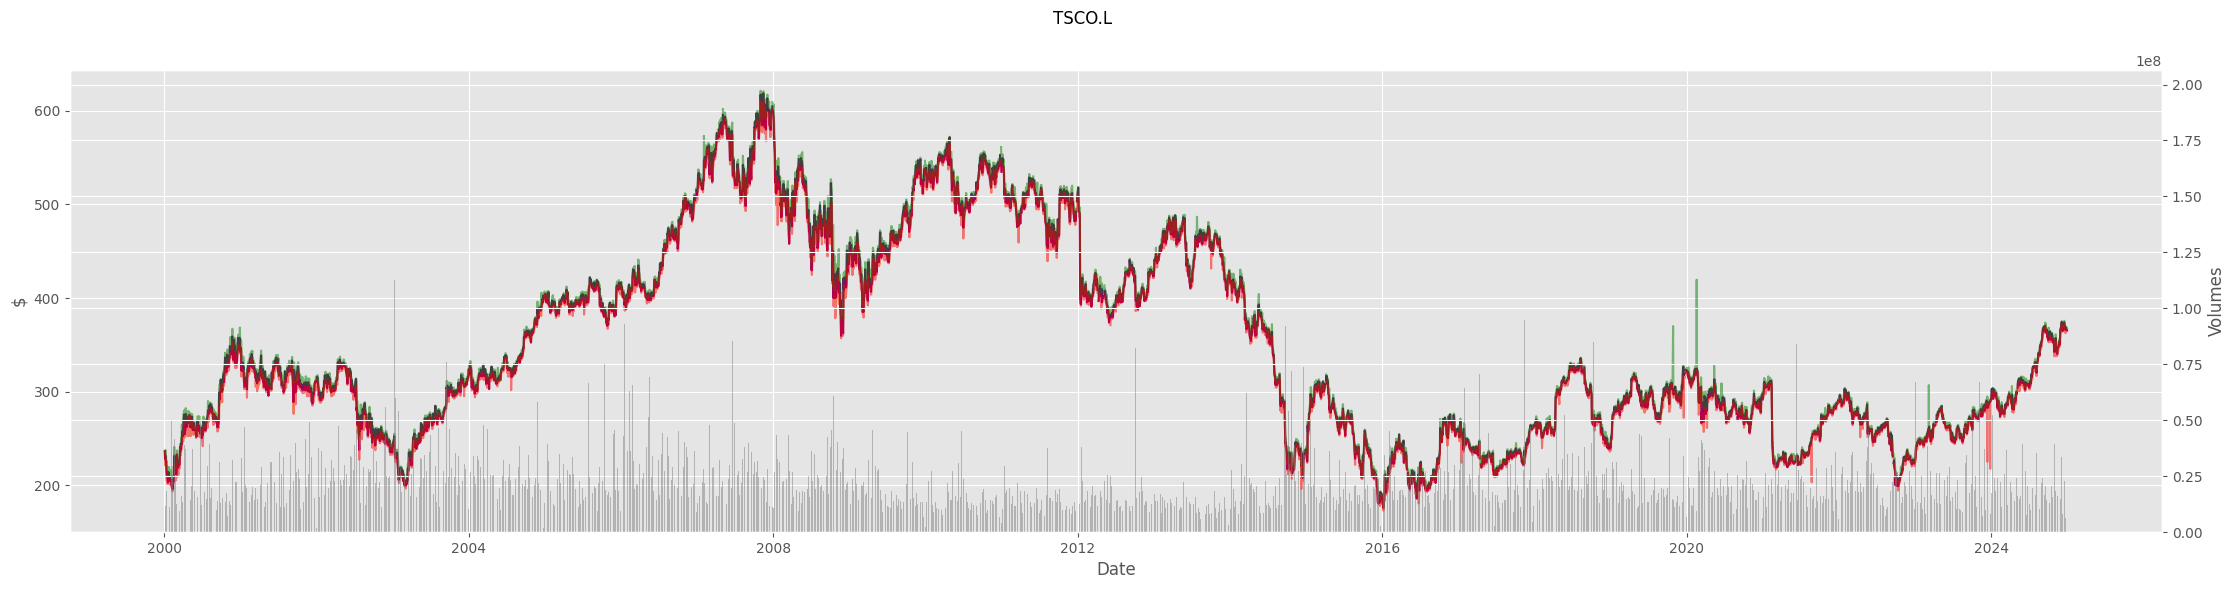

In [19]:
plot_ticker("TSCO.L")

In [20]:
from pandas import DataFrame

small_imputation_tickers: DataFrame = tickers.copy()

limit: int = 2

small_imputation_tickers["Close"] = small_imputation_tickers["Close"].ffill(limit = limit)
small_imputation_tickers["Open"] = small_imputation_tickers["Open"].ffill(limit = limit)
small_imputation_tickers["Low"] = small_imputation_tickers["Low"].ffill(limit = limit)
small_imputation_tickers["High"] = small_imputation_tickers["High"].ffill(limit = limit)
small_imputation_tickers["Volume"] = small_imputation_tickers["Volume"].ffill(limit = limit)

In [21]:
small_imputation_tickers.isna().sum()

Price   Ticker
Close   AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
High    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Low     AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Open    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Volume  AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
dtype: int64

In [22]:
small_imputation_tickers[small_imputation_tickers.isna().any(axis = 1)]

Price      Close                                   High                        \
Ticker      AAPL HSBC      LLOY.L NVDA      TSCO.L AAPL HSBC      LLOY.L NVDA   
Date                                                                            
2001-09-13   NaN  NaN  437.597382  NaN  315.028473  NaN  NaN  437.597382  NaN   
2001-09-14   NaN  NaN  419.578613  NaN  322.872650  NaN  NaN  438.884426  NaN   

Price                   ... Open                                   Volume  \
Ticker          TSCO.L  ... AAPL HSBC      LLOY.L NVDA      TSCO.L   AAPL   
Date                    ...                                                 
2001-09-13  315.028473  ...  NaN  NaN  437.597382  NaN  311.539252    NaN   
2001-09-14  331.344551  ...  NaN  NaN  419.578613  NaN  315.028385    NaN   

Price                                         
Ticker     HSBC      LLOY.L NVDA      TSCO.L  
Date                                          
2001-09-13  NaN  26036252.0  NaN  22200826.0  
2001-09-14  NaN  26752117.0  NaN  24419843.0  

[2 rows x 25 columns]

In [23]:
small_imputation_tickers.dropna(inplace = False)

Price            Close                                                 \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L   
Date                                                                    
2000-01-03    0.839281  19.393660  497.945465    0.089415  236.190338   
2000-01-04    0.768521  18.210487  466.763641    0.087028  228.034912   
2000-01-05    0.779767  18.107616  466.120697    0.084163  231.798935   
2000-01-06    0.712287  17.593191  450.690552    0.078671  231.798935   
2000-01-07    0.746027  18.090469  434.938721    0.079985  228.662292   
...                ...        ...         ...         ...         ...   
2024-12-23  254.120667  46.123508   53.933956  139.631790  365.866791   
2024-12-24  257.037476  46.653984   54.193832  140.181656  368.365875   
2024-12-26  257.853760  46.663460   54.193832  139.891724  368.365875   
2024-12-27  254.439224  46.691875   54.333767  136.972534  366.766449   
2024-12-30  251.064484  46.900280   54.393734  137.452393  365.466949   

Price             High                                                 ...  \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L  ...   
Date                                                                   ...   
2000-01-03    0.843498  19.616575  497.945465    0.090967  236.190338  ...   
2000-01-04    0.829440  18.656319  466.763641    0.088102  237.131283  ...   
2000-01-05    0.828971  18.193353  466.120697    0.085953  233.994635  ...   
2000-01-06    0.802260  17.661781  450.690552    0.084163  234.621934  ...   
2000-01-07    0.757274  18.090469  434.938721    0.080820  237.131273  ...   
...                ...        ...         ...         ...         ...  ...   
2024-12-23  254.498945  46.151930   54.473696  139.751752  367.666123  ...   
2024-12-24  257.047410  46.701348   54.553659  141.861189  369.165572  ...   
2024-12-26  258.928914  46.852918   54.553659  140.811485  369.165572  ...   
2024-12-27  257.535238  46.720293   54.433717  138.981994  368.865691  ...   
2024-12-30  252.358634  47.042375   54.653611  140.231631  367.766100  ...   

Price             Open                                                 \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L   
Date                                                                    
2000-01-03    0.786328  19.599428  497.945465    0.090251  236.190338   
2000-01-04    0.811633  18.399108  466.763641    0.087863  237.131283   
2000-01-05    0.777893  17.764669  466.120697    0.084521  220.820663   
2000-01-06    0.795700  17.558896  450.690552    0.084163  231.798935   
2000-01-07    0.723534  17.490312  434.938721    0.078313  234.621879   
...                ...        ...         ...         ...         ...   
2024-12-23  253.622918  45.649864   54.053901  136.242718  364.667215   
2024-12-24  254.339671  46.170868   54.553659  139.961715  366.766452   
2024-12-26  257.027510  46.701352   54.553659  139.661791  366.766452   
2024-12-27  256.669129  46.445578   54.113872  138.512122  368.365873   
2024-12-30  251.094347  46.625569   54.053902  134.793117  366.266646   

Price            Volume                                                   
Ticker             AAPL       HSBC       LLOY.L         NVDA      TSCO.L  
Date                                                                      
2000-01-03  535796800.0    59500.0          0.0  300912000.0         0.0  
2000-01-04  512377600.0    84500.0   21285517.0  300480000.0  11214410.0  
2000-01-05  778321600.0   118200.0   26030803.0  188352000.0   9228302.0  
2000-01-06  767972800.0   105400.0   43870695.0  120480000.0  11398336.0  
2000-01-07  460734400.0   117700.0   38938371.0   71184000.0  13505834.0  
...                 ...        ...          ...          ...         ...  
2024-12-23   40858800.0   854300.0  193151547.0  176053500.0   6240707.0  
2024-12-24   23234700.0   309000.0   70289585.0  105157000.0   3125759.0  
2024-12-26   27237100.0   516300.0  

In [24]:
small_imputation_tickers.isna().sum()

Price   Ticker
Close   AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
High    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Low     AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Open    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Volume  AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
dtype: int64

# Preparing the dependant variable y, excess returns 

We'll select Apple, AAPL as the target ticker arbitrarily, however, realistically it could have been valid ticker

In [34]:
from pandas import Series

# pct_change() returns in format 0.01 = 1% thus we must change the format to match FF 0.01 = 1% -> 1.00 = 1%
# dropna() for the first sample given pct_change() cannot calculate the change from one value
total_returns: Series = (small_imputation_tickers["Close"].pct_change()) * 100
total_returns.dropna(inplace = True)

/tmp/ipykernel_8817/1977192223.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  total_returns: Series = (small_imputation_tickers["Close"].pct_change()) * 100


In [35]:
total_returns.head()

Ticker,AAPL,HSBC,LLOY.L,NVDA,TSCO.L
Date,,,,,
2000-01-04,-8.431002,-6.100820,-6.262096,-2.670079,-3.452904
2000-01-05,1.463326,-0.564899,-0.137745,-3.292150,1.650634
2000-01-06,-8.653856,-2.840933,-3.310333,-6.525293,0.000000
2000-01-07,4.736919,2.826538,-3.495044,1.670014,-1.353174
2000-01-10,-1.758800,0.094785,2.808581,3.282929,-3.155013


In [36]:
from pandas import merge, DataFrame

ticker: str = "AAPL"

data: DataFrame = merge(total_returns[ticker], fama_french, how = "inner", left_index = True, right_index = True)
data.rename(columns = {ticker: "Excess Returns"}, inplace = True) # value is wrong but will correct that in after merging

In [37]:
data.head()

,Excess Returns,Mkt-RF,SMB,HML,RMW,CMA,RF
2000-01-04,-8.431002,-4.06,0.34,2.07,0.53,1.36,0.02
2000-01-05,1.463326,-0.09,0.36,-0.05,0.45,1.15,0.02
2000-01-06,-8.653856,-0.74,-0.04,1.24,0.64,1.21,0.02
2000-01-07,4.736919,3.21,-0.89,-1.57,-0.83,-1.00,0.02
2000-01-10,-1.758800,1.75,0.43,-1.35,-2.20,-0.24,0.02


In [38]:
data["Excess Returns"] = data["Excess Returns"] - data["RF"]
data.drop(columns = {"RF"}, inplace = True) # don't particularly need it for training 

In [39]:
data.head()

,Excess Returns,Mkt-RF,SMB,HML,RMW,CMA
2000-01-04,-8.451002,-4.06,0.34,2.07,0.53,1.36
2000-01-05,1.443326,-0.09,0.36,-0.05,0.45,1.15
2000-01-06,-8.673856,-0.74,-0.04,1.24,0.64,1.21
2000-01-07,4.716919,3.21,-0.89,-1.57,-0.83,-1.00
2000-01-10,-1.778800,1.75,0.43,-1.35,-2.20,-0.24


In [40]:
data.isna().sum()

Excess Returns    0
Mkt-RF            0
SMB               0
HML               0
RMW               0
CMA               0
dtype: int64

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6287 entries, 2000-01-04 to 2024-12-30
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Excess Returns  6287 non-null   float64
 1   Mkt-RF          6287 non-null   float64
 2   SMB             6287 non-null   float64
 3   HML             6287 non-null   float64
 4   RMW             6287 non-null   float64
 5   CMA             6287 non-null   float64
dtypes: float64(6)
memory usage: 343.8 KB


Text(0.5, 0, 'Date')

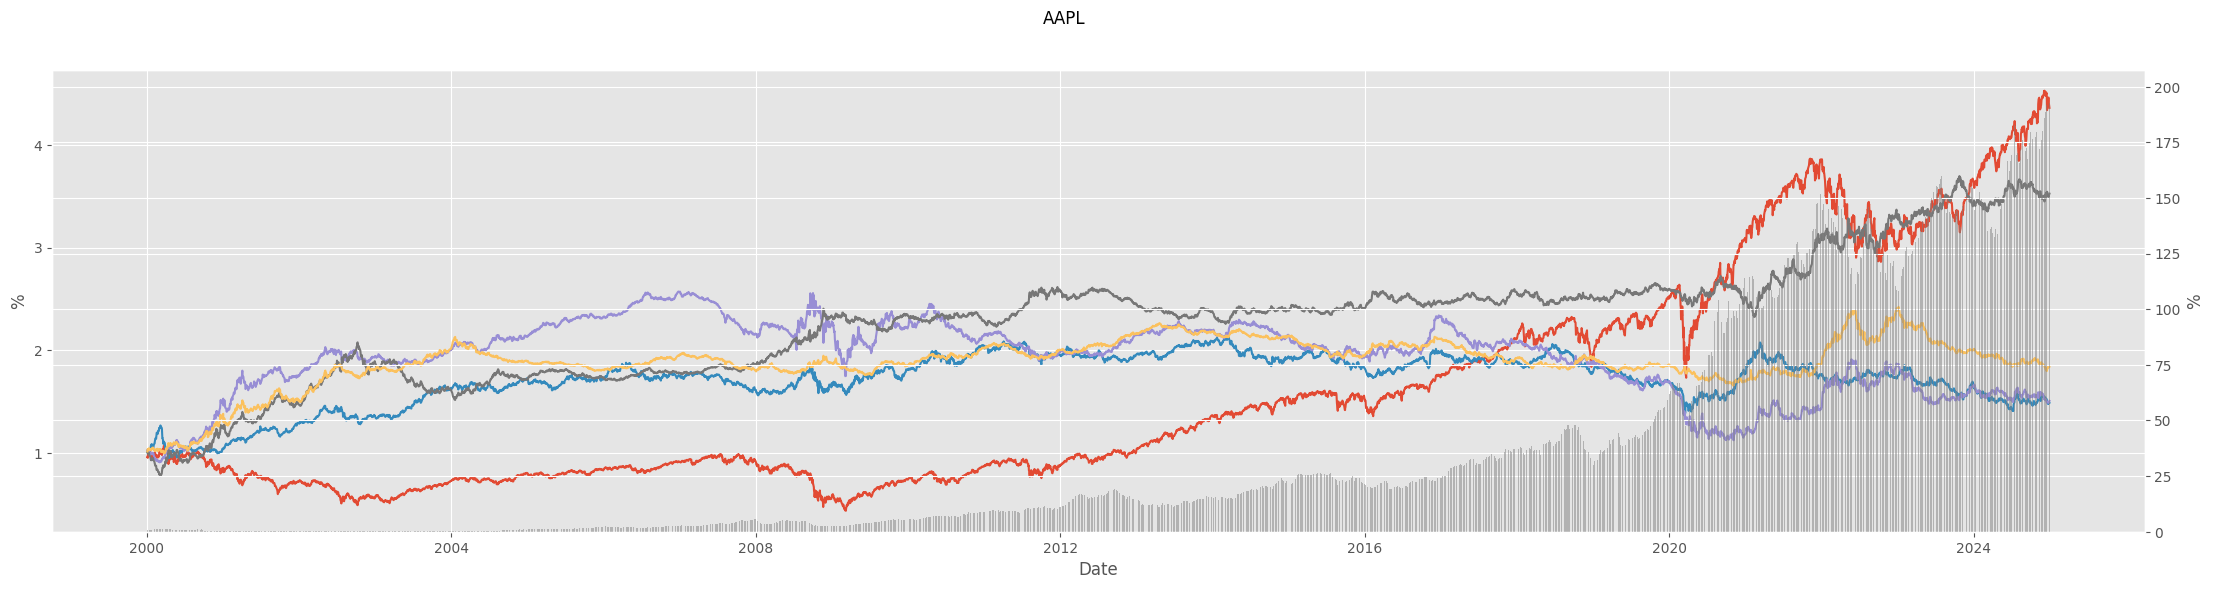

In [42]:
import matplotlib.pyplot as plt
from pandas import DataFrame

plt.style.use("ggplot")

data_percentage: DataFrame = (1 + data / 100) # converts ie. 1.00 = 1% -> 0.01 = 1%
data_percentage_cumprod: DataFrame = data_percentage.cumprod()

figure, axes = plt.subplots(1, 1)
figure.set_figwidth(27)
figure.set_figheight(6)
figure.suptitle(ticker)

axes.plot(data_percentage_cumprod["Mkt-RF"])
axes.plot(data_percentage_cumprod["SMB"])
axes.plot(data_percentage_cumprod["HML"])
axes.plot(data_percentage_cumprod["RMW"])
axes.plot(data_percentage_cumprod["CMA"])
axes.set_ylabel("%")
axes.set_xlabel("Date")
axes_ext: ax.Axes = axes.twinx()

axes_ext.bar(data_percentage_cumprod.index, data_percentage_cumprod["Excess Returns"], color = "grey", alpha = 0.5)
axes_ext.set_ylabel("%")
axes_ext.set_xlabel("Date")

# Multi-linear algorithm definition

In [45]:
import numpy as np

class Metrics():
  @classmethod
  def mean_squared(cls, error: np.ndarray) -> float:
    m: int = error.shape[0]
    return ((error.T @ error) * (1 / m)).item()

  @classmethod
  def root_mean_squared(cls, error: np.ndarray) -> float:
    return np.sqrt(cls.mean_squared(error))

  @classmethod
  def r_squared(cls, error: np.ndarray, variance: np.ndarray) -> float:
    return (1 - ((error.T @ error) / (variance.T @ variance))).item()

In [76]:
import numpy as np

class Multi_Linear_Regression:
  C: np.ndarray 
  M: np.ndarray 

  def train(self, x_train: np.ndarray, y_train: np.ndarray, lr: float = 1e-5, epoch: int = 1000) -> None:
    m, n = x_train.shape[0], x_train.shape[1]

    self.M: np.ndarray = np.ones((n, 1))
    self.C: np.ndarray = np.ones((1, 1))
    for _ in range(epoch): 
      y_hat: np.ndarray = (x_train @ self.M) + self.C
      error: np.ndarray = y_hat - y_train

      M_der: np.ndarray = (x_train.T @ error) * (2 / m)
      C_der: np.ndarray = (np.ones(m) @ error) * (2 / m)

      self.C: np.ndarray = self.C - (lr * C_der)
      self.M: np.ndarray = self.M - (lr * M_der)
  
  def predict(self, x_test: np.ndarray) -> np.ndarray | float:
    results: np.ndarray = (x_test @ self.M) + self.C

    if len(results) == 1: return results.item()
    return results


# Pre-training test

In [77]:
from pandas import DataFrame

x: DataFrame = data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
y: DataFrame = data[["Excess Returns"]]

In [48]:
x.head()

,Mkt-RF,SMB,HML,RMW,CMA
2000-01-04,-4.06,0.34,2.07,0.53,1.36
2000-01-05,-0.09,0.36,-0.05,0.45,1.15
2000-01-06,-0.74,-0.04,1.24,0.64,1.21
2000-01-07,3.21,-0.89,-1.57,-0.83,-1.00
2000-01-10,1.75,0.43,-1.35,-2.20,-0.24


In [49]:
y.head()

,Excess Returns
2000-01-04,-8.451002
2000-01-05,1.443326
2000-01-06,-8.673856
2000-01-07,4.716919
2000-01-10,-1.778800


In [78]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# testing the correlation of the data to the market to determine if there even is a correlation to begin with
split: TimeSeriesSplit = TimeSeriesSplit(n_splits = 5)
mean_squared_errors: list = []
root_mean_squared_errors: list = []
r1_scores: list = []

for fold, (train_index, test_index) in enumerate(split.split(x)):
  x_train: np.ndarray = x.iloc[train_index].values
  x_test: np.ndarray = x.iloc[test_index].values
  y_train: np.ndarray = y.iloc[train_index].values
  y_test: np.ndarray = y.iloc[test_index].values

  model: Multi_Linear_Regression = Multi_Linear_Regression()
  model.train(x_train, y_train, lr = 2e-3,epoch = 10000)  

  y_predict: np.ndarray | float = model.predict(x_test)

  mean: np.ndarray = np.mean(y_test, dtype = np.ndarray)
  variance: np.ndarray = y_test - mean
  error: np.ndarray = y_predict - y_test
  
  mean_squared_errors.append(mean_squared_error := Metrics.mean_squared(error))
  root_mean_squared_errors.append(root_mean_squared_error := Metrics.mean_squared(error))
  r1_scores.append(r1_score := Metrics.r_squared(error, variance))

  print(f"Fold: {fold:02}, Mean squared error: {mean_squared_error:2.5f} | Root mean squared error: {root_mean_squared_error:2.5f} | R1 score: {r1_score:2.5f} \n")

print(f"Averages, Mean squared error: {np.mean(mean_squared_errors):2.5f} | Root mean squared error: {np.mean(root_mean_squared_errors):2.5f} | R1 score: {np.mean(r1_scores):2.5f}")

Fold: 00, Mean squared error: 4.88952 | Root mean squared error: 4.88952 | R1 score: 0.22691 

Fold: 01, Mean squared error: 2.74217 | Root mean squared error: 2.74217 | R1 score: 0.48608 

Fold: 02, Mean squared error: 2.03714 | Root mean squared error: 2.03714 | R1 score: 0.24810 

Fold: 03, Mean squared error: 1.53350 | Root mean squared error: 1.53350 | R1 score: 0.59341 

Fold: 04, Mean squared error: 1.69915 | Root mean squared error: 1.69915 | R1 score: 0.40459 

Averages, Mean squared error: 2.58030 | Root mean squared error: 2.58030 | R1 score: 0.39182


# Training the model

In [79]:
from pandas import DataFrame

training_date: str = "2020-01-01"
train_testing_split_date: str = "2024-12-01"

data_window: DataFrame = data[data.index >= training_date]
x: DataFrame = data_window[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
y: DataFrame = data_window[["Excess Returns"]]

x_train: DataFrame = x[x.index <= train_testing_split_date]
y_train: DataFrame = y[y.index <= train_testing_split_date]
x_test: DataFrame = x[x.index > train_testing_split_date]
y_test: DataFrame = y[y.index > train_testing_split_date]

In [56]:
x_train.tail()

,Mkt-RF,SMB,HML,RMW,CMA
2024-11-22,0.53,1.40,0.42,-0.68,-0.63
2024-11-25,0.41,1.29,0.23,0.07,-0.46
2024-11-26,0.42,-1.07,-0.67,0.54,-0.35
2024-11-27,-0.40,0.44,0.47,-0.60,0.10
2024-11-29,0.54,-0.05,-0.64,-0.05,0.32


In [57]:
y_train.tail()

,Excess Returns
2024-11-22,0.570743
2024-11-25,1.285087
2024-11-26,0.920441
2024-11-27,-0.075309
2024-11-29,1.001592


In [58]:
x_test.head()

,Mkt-RF,SMB,HML,RMW,CMA
2024-12-02,0.23,0.19,-0.65,0.52,-0.39
2024-12-03,0.04,-0.78,-0.56,0.36,-0.14
2024-12-04,0.70,-0.19,-1.26,-1.09,-0.05
2024-12-05,-0.28,-0.96,0.48,0.54,-0.11
2024-12-06,0.35,0.39,-1.06,-1.07,-0.70


In [59]:
y_test.head()

,Excess Returns
2024-12-02,0.932257
2024-12-03,1.257174
2024-12-04,0.128370
2024-12-05,-0.007663
2024-12-06,-0.102284


In [ ]:
mlr: Multi_Linear_Regression = Multi_Linear_Regression()
window: int = 100

predictions = []
dates = []

for i in range(window, len(x)):
  x_window = x.iloc[i - window: i]
  y_window = y.iloc[i - window: i]

  mlr.train(x_window.values, y_window.values)

  predictions.append(mlr.predict(x.iloc[[i]].values[0]))
  dates.append(x.index[i])

In [ ]:
from pandas import DataFrame
from scipy import stats

results = DataFrame(data = predictions, index = dates, columns = ['Expected_Return'])
results['Actual_Return'] = y.loc[results.index]
results['Alpha'] = results['Actual_Return'] - results['Expected_Return']

t_stats, p_value = stats.ttest_1samp(results['Alpha'], 0)

In [84]:
results["Alpha"]

2020-05-27   -7.804166
2020-05-28    3.764541
2020-05-29    1.663953
2020-06-01   -0.664221
2020-06-02   -2.245227
                ...   
2024-12-23   -1.212731
2024-12-24   -0.313701
2024-12-26   -1.513978
2024-12-27   -1.720486
2024-12-30   -2.907162
Name: Alpha, Length: 1157, dtype: float64

In [83]:
print(f"T-Stats: {t_stats}")
print(f"P-Value: {p_value}")

T-Stats: -12.805374584772357
P-Value: 3.3327711887748544e-35


# sdf

In [ ]:
import json

model: Multi_Linear_Regression = Multi_Linear_Regression()
model.train(x.values, y.values) 

model_data: dict = {
  "C": float(model.C.item()),
  "M": model.M.tolist()
}

with open("fama_french_parameters.json", "w") as file:
  json.dump(model_data, file) 